In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pytz

from sklearn.metrics import r2_score

In [17]:
def preprocess_RAW(file_path):
    sensor = pd.read_csv(file_path, parse_dates=['timestamp'])
    sensor = sensor[['timestamp_local','rh','temp','pm25']].dropna(subset=['pm25'])
    sensor.rename(columns={'timestamp_local':'time'}, inplace=True)
    
    sensor['time'] = pd.to_datetime(sensor['time'])
    est = pytz.timezone('US/Eastern')
    sensor['time'] = sensor['time'].dt.tz_convert(est)
    sensor['time'] = sensor['time'].dt.strftime('%Y-%m-%d %H:%M:%S')
    sensor['time'] = pd.to_datetime(sensor['time'])
    sensor['day'] = sensor['time'].dt.date
    sensor['dayhour'] = sensor['time'].dt.strftime('%Y-%m-%d %H')

    sensor = sensor.groupby('dayhour').agg(
        pm25=('pm25', lambda x: x.mean(skipna=True)),
    ).reset_index()
    sensor = sensor.sort_values(by='dayhour')
    return sensor[['dayhour', 'pm25']]

def preprocess_PRED(file_path):
    pred = pd.read_csv(file_path)
    pred = pred[['dayhour','corrected_PM25h']].dropna(subset=['corrected_PM25h'])
    pred.rename(columns={'corrected_PM25h':'pm25'}, inplace=True)

    pred = pred.sort_values('dayhour')
    return pred[['dayhour', 'pm25']]

def preprocess_GAPA(file_path):
    gapa = pd.read_csv(file_path, header=2)
    gapa.columns = ['Date', 'PMHR_2', 'PMHR', 'PMHR25', '24H_PMHR25', 'PMHRC', 'pm25']
    gapa = gapa[['Date', 'PMHR']]
    # return gapa

    gapa['time'] = pd.to_datetime(gapa['Date'], format='%d-%b-%Y %H:%M')
    gapa['day'] = gapa['time'].dt.strftime("%Y-%m-%d")
    gapa['day'] = pd.to_datetime(gapa['day']).dt.date
    gapa['dayhour'] = gapa['time'].dt.strftime("%Y-%m-%d %H")
    gapa = gapa[['day','dayhour','PMHR']]
    gapa.rename(columns={'PMHR':'rpm25'}, inplace=True)
    gapa.dropna(subset=['rpm25'], inplace=True)

    h_gapa = gapa.groupby('dayhour').agg(
        pm25=('rpm25', lambda x: x.mean(skipna=True)),
    ).reset_index()

    h_gapa = h_gapa.sort_values('dayhour')

    h_gapa['pm25'] = h_gapa['pm25'].replace(to_replace=0, value=np.nan)

    return h_gapa[['dayhour', 'pm25']]



0.725085592076719


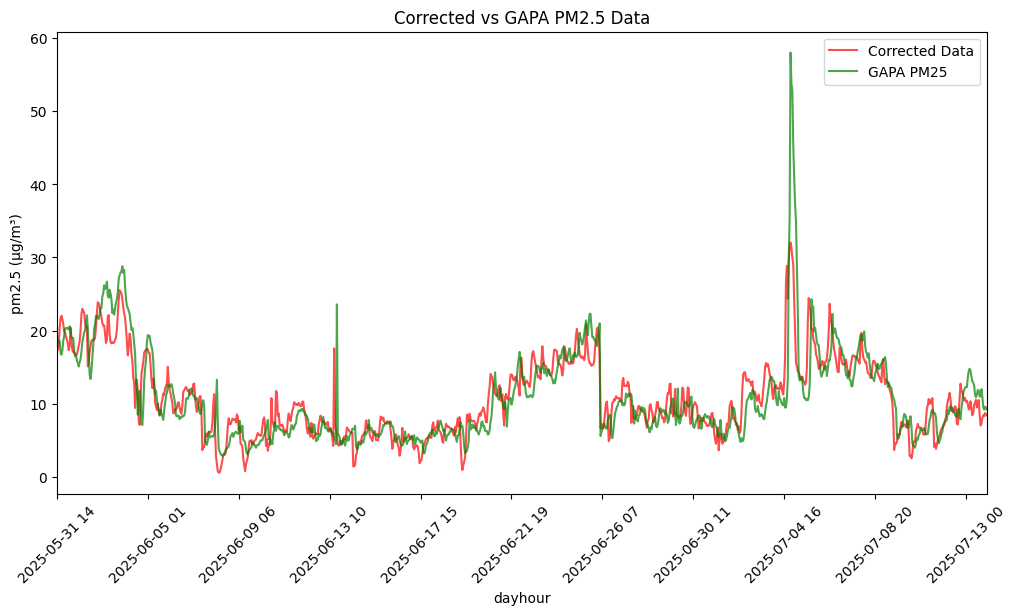

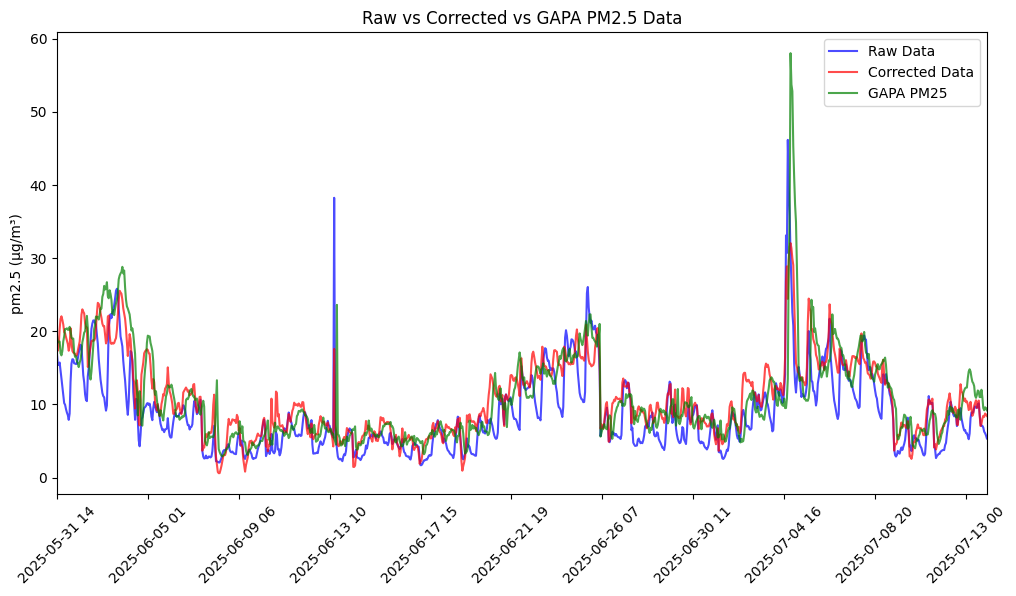

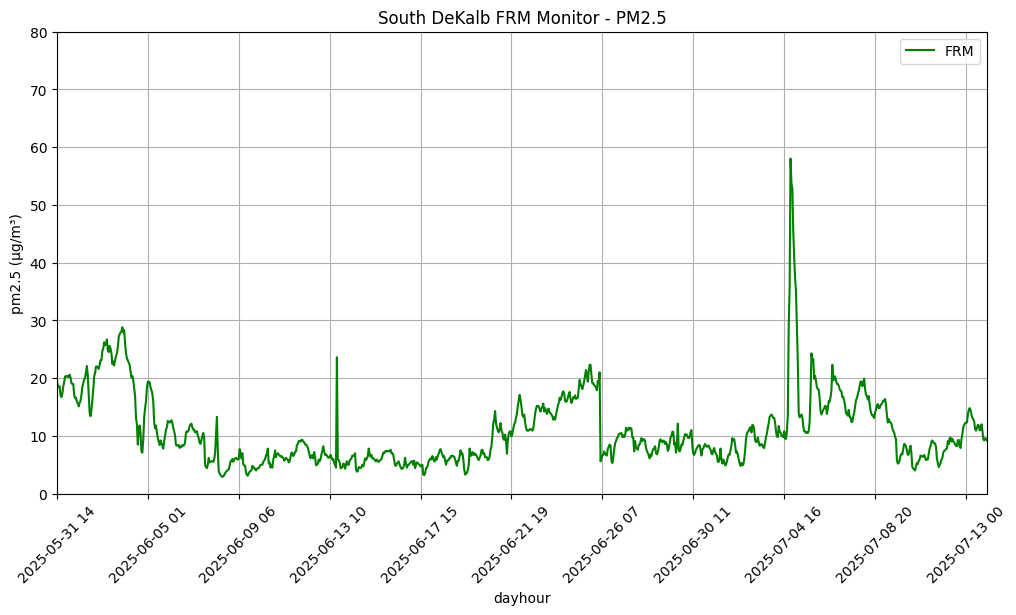

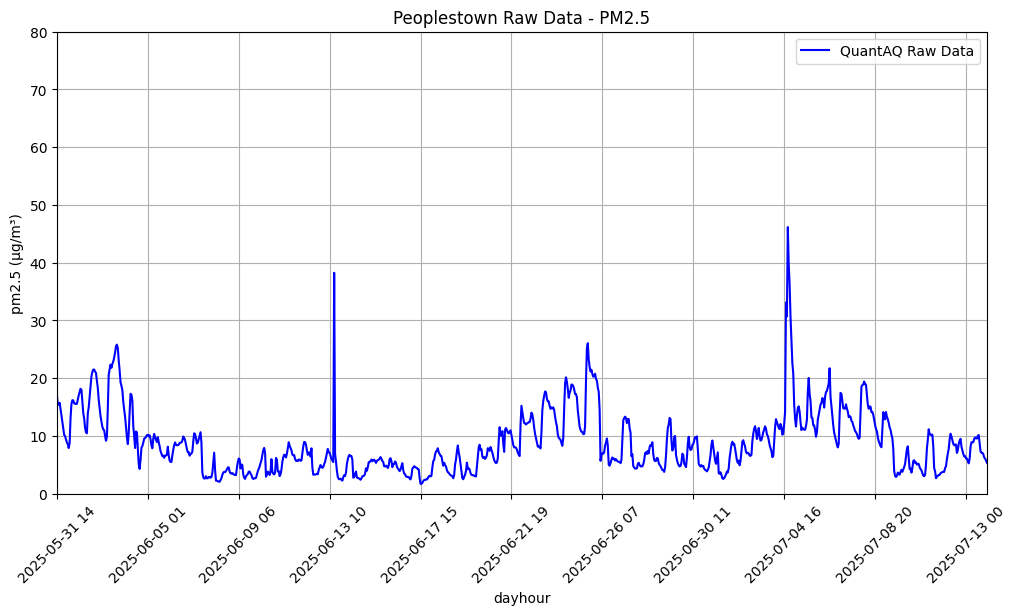

In [18]:
# create a figure with 3 subplots, raw, corrected, and GAPA
# fig, axs = plt.subplots(3, 1, figsize=(10, 15))
# axs[0].set_title('Raw Data')
# axs[1].set_title('Corrected Data')
# axs[2].set_title('GAPA Data')

# 1 plot with 3 lines


# read the data from csv files and preprocess
raw_data = preprocess_RAW('../ShortenedData/MOD-00590-RAW.csv')
corrected_data = preprocess_PRED('Predictions/hMOD-00590-PRED.csv')
# corrected_data = preprocess_PRED('hourly_model_predictions.csv')
gapa_data = preprocess_GAPA('PM10&PM2.5.csv')

# ensure all data have the same dayhour values
common_dayhours = set(raw_data['dayhour']).intersection(set(corrected_data['dayhour'])).intersection(set(gapa_data['dayhour']))
raw_data = raw_data[raw_data['dayhour'].isin(common_dayhours)]
corrected_data = corrected_data[corrected_data['dayhour'].isin(common_dayhours)]
gapa_data = gapa_data[gapa_data['dayhour'].isin(common_dayhours)]

r2 = r2_score(gapa_data['pm25'], corrected_data['pm25'])
print(r2)


# plot the data
plt.figure(figsize=(12, 6))
plt.plot(corrected_data['dayhour'], corrected_data['pm25'], label='Corrected Data', color='red', alpha=0.7)
plt.plot(gapa_data['dayhour'], gapa_data['pm25'], label='GAPA PM25', color='green', alpha=0.7)

# Add title and labels
plt.title('Multiple Lines on a Single Plot')
plt.xlabel('dayhour')
plt.ylabel(f'pm2.5 (μg/m\u00B3)')
plt.xticks(corrected_data['dayhour'][::100], rotation=45) # Show every 100th tick
plt.xlim(corrected_data['dayhour'].min(), corrected_data['dayhour'].max())
plt.legend()
plt.title("Corrected vs GAPA PM2.5 Data")
plt.show() # plot with no raw data

# plot including raw
plt.figure(figsize=(12, 6))
plt.plot(raw_data['dayhour'], raw_data['pm25'], label='Raw Data', color='blue', alpha=0.7)
plt.plot(corrected_data['dayhour'], corrected_data['pm25'], label='Corrected Data', color='red', alpha=0.7)
plt.plot(gapa_data['dayhour'], gapa_data['pm25'], label='GAPA PM25', color='green', alpha=0.7)
plt.xticks(corrected_data['dayhour'][::100], rotation=45) # Show every 100th tick
plt.xlim(corrected_data['dayhour'].min(), corrected_data['dayhour'].max())
plt.ylabel(f'pm2.5 (μg/m\u00B3)')
plt.legend()
plt.title("Raw vs Corrected vs GAPA PM2.5 Data")
plt.show()


plt.figure(figsize=(12, 6))
plt.plot(gapa_data['dayhour'], gapa_data['pm25'], label='FRM', color='green')
plt.xlabel('dayhour')
plt.ylabel(f'pm2.5 (μg/m\u00B3)')
plt.xticks(gapa_data['dayhour'][::100], rotation=45) # Show every 100th tick
plt.xlim(gapa_data['dayhour'].min(), corrected_data['dayhour'].max())
plt.ylim(0, 80)
plt.legend()
plt.title("South DeKalb FRM Monitor - PM2.5")
plt.grid()
plt.show()


plt.figure(figsize=(12, 6))
plt.plot(raw_data['dayhour'], raw_data['pm25'], label='QuantAQ Raw Data', color='blue')
plt.xlabel('dayhour')
plt.ylabel(f'pm2.5 (μg/m\u00B3)')
plt.xticks(raw_data['dayhour'][::100], rotation=45) # Show every 100th tick
plt.xlim(raw_data['dayhour'].min(), corrected_data['dayhour'].max())
plt.ylim(0, 80)
plt.legend()
plt.title("Peoplestown Raw Data - PM2.5")
plt.grid()
plt.show()
